In [1]:
import os
print(os.getcwd())

C:\Users\DELL\Decision-trees-classification


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\loan_default_data.csv")

In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['customer_id', 'age', 'annual_income', 'credit_score', 'loan_amount',
       'loan_tenure_months', 'interest_rate', 'dti', 'utilization',
       'days_past_due', 'inquiries_6m', 'existing_loans', 'employment_type',
       'default'],
      dtype='object')

In [6]:
df["default"].value_counts(dropna=False)

default
0    8574
1    1426
Name: count, dtype: int64

In [7]:
df.isna().sum()

customer_id             0
age                     0
annual_income         200
credit_score          150
loan_amount             0
loan_tenure_months      0
interest_rate           0
dti                   100
utilization             0
days_past_due           0
inquiries_6m            0
existing_loans          0
employment_type         0
default                 0
dtype: int64

In [8]:
df.dtypes

customer_id            object
age                     int64
annual_income         float64
credit_score          float64
loan_amount             int64
loan_tenure_months      int64
interest_rate         float64
dti                   float64
utilization           float64
days_past_due           int64
inquiries_6m            int64
existing_loans          int64
employment_type        object
default                 int64
dtype: object

In [9]:
df.head(5)

,customer_id,age,annual_income,credit_score,loan_amount,loan_tenure_months,interest_rate,dti,utilization,days_past_due,inquiries_6m,existing_loans,employment_type,default
0,C00001,25,355158.0,620.0,249337,12,19.40,0.431,0.387,0,2,1,Salaried,0
1,C00002,55,482630.0,686.0,353779,36,19.36,0.440,0.054,0,2,3,Salaried,0
2,C00003,50,754891.0,662.0,541278,36,18.52,0.616,0.605,29,0,2,Salaried,0
3,C00004,40,460078.0,751.0,606237,48,14.59,0.370,0.669,92,0,2,Self-employed,0
4,C00005,40,557728.0,754.0,430453,60,14.24,0.331,0.584,21,2,1,Salaried,0


In [10]:
(df["default"].value_counts(normalize=True, dropna=False) * 100).round(2)

default
0    85.74
1    14.26
Name: proportion, dtype: float64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         10000 non-null  object 
 1   age                 10000 non-null  int64  
 2   annual_income       9800 non-null   float64
 3   credit_score        9850 non-null   float64
 4   loan_amount         10000 non-null  int64  
 5   loan_tenure_months  10000 non-null  int64  
 6   interest_rate       10000 non-null  float64
 7   dti                 9900 non-null   float64
 8   utilization         10000 non-null  float64
 9   days_past_due       10000 non-null  int64  
 10  inquiries_6m        10000 non-null  int64  
 11  existing_loans      10000 non-null  int64  
 12  employment_type     10000 non-null  object 
 13  default             10000 non-null  int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 1.1+ MB


In [12]:
print("Unique customer IDs:", df["customer_id"].nunique())
print("Exact duplicate rows:", df.duplicated().sum())

Unique customer IDs: 10000
Exact duplicate rows: 0


In [13]:
X = df.drop(columns=["customer_id", "days_past_due", "default"])
y = df["default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
X_train.shape

(8000, 11)

In [16]:
X_test.shape

(2000, 11)

In [17]:
y_train.value_counts()

default
0    6859
1    1141
Name: count, dtype: int64

In [18]:
y_test.value_counts()

default
0    1715
1     285
Name: count, dtype: int64

In [19]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'annual_income', 'credit_score', 'loan_amount', 'loan_tenure_months', 'interest_rate', 'dti', 'utilization', 'inquiries_6m', 'existing_loans']
Categorical: ['employment_type']


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [21]:
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.764


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

[[1458  257]
 [ 215   70]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1715
           1       0.21      0.25      0.23       285

    accuracy                           0.76      2000
   macro avg       0.54      0.55      0.54      2000
weighted avg       0.78      0.76      0.77      2000



In [24]:
tree = model.named_steps["tree"]

print("Tree depth:", tree.get_depth())
print("Number of leaves:", tree.get_n_leaves())

Tree depth: 24
Number of leaves: 1070


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "tree__max_depth": [3, 5, 8, 12],
    "tree__min_samples_leaf": [5, 10, 20, 50]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best parameters: {'tree__max_depth': 5, 'tree__min_samples_leaf': 50}
Best CV ROC-AUC: 0.6934632112166452


In [26]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)

best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, zero_division=0))

Test accuracy: 0.8555
Test ROC-AUC: 0.6930755460078768
Confusion matrix:
 [[1704   11]
 [ 278    7]]
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1715
           1       0.39      0.02      0.05       285

    accuracy                           0.86      2000
   macro avg       0.62      0.51      0.48      2000
weighted avg       0.79      0.86      0.80      2000



In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score
import numpy as np

oof_prob = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    oof_pred = (oof_prob >= threshold).astype(int)
    print(
        threshold,
        "precision:", round(precision_score(y_train, oof_pred, zero_division=0), 3),
        "recall:", round(recall_score(y_train, oof_pred, zero_division=0), 3)
    )

0.1 precision: 0.193 recall: 0.788
0.2 precision: 0.28 recall: 0.394
0.3 precision: 0.328 recall: 0.233
0.4 precision: 0.369 recall: 0.129
0.5 precision: 0.415 recall: 0.062


In [28]:
threshold = 0.10
y_test_pred_10 = (y_test_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_test_pred_10))
print(classification_report(y_test, y_test_pred_10, zero_division=0))

[[737 978]
 [ 58 227]]
              precision    recall  f1-score   support

           0       0.93      0.43      0.59      1715
           1       0.19      0.80      0.30       285

    accuracy                           0.48      2000
   macro avg       0.56      0.61      0.45      2000
weighted avg       0.82      0.48      0.55      2000



In [29]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["tree"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
2,num__credit_score,0.442212
7,num__utilization,0.263456
6,num__dti,0.237815
0,num__age,0.015980
5,num__interest_rate,0.015788
9,num__existing_loans,0.013619
1,num__annual_income,0.006580
13,cat__employment_type_Unemployed,0.004550
3,num__loan_amount,0.000000
4,num__loan_tenure_months,0.000000


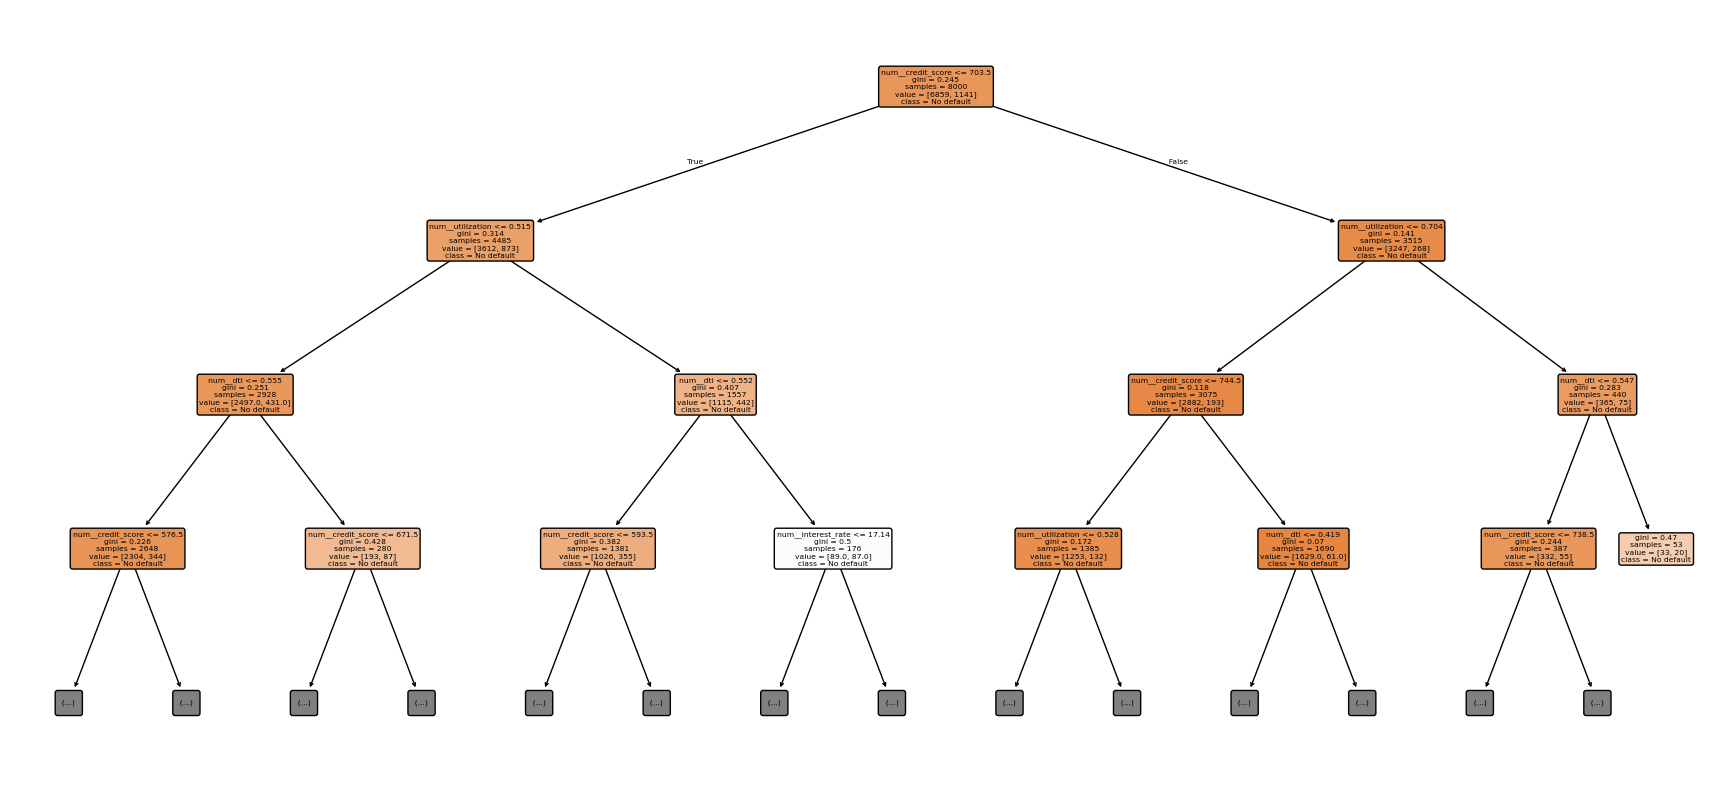

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    best_model.named_steps["tree"],
    feature_names=feature_names,
    class_names=["No default", "Default"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.show()

In [31]:
from sklearn.tree import export_text

print(export_text(
    best_model.named_steps["tree"],
    feature_names=list(feature_names),
    max_depth=5
))

|--- num__credit_score <= 703.50
|   |--- num__utilization <= 0.52
|   |   |--- num__dti <= 0.55
|   |   |   |--- num__credit_score <= 576.50
|   |   |   |   |--- num__utilization <= 0.29
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__utilization >  0.29
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__credit_score >  576.50
|   |   |   |   |--- num__dti <= 0.20
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__dti >  0.20
|   |   |   |   |   |--- class: 0
|   |   |--- num__dti >  0.55
|   |   |   |--- num__credit_score <= 671.50
|   |   |   |   |--- num__utilization <= 0.40
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__utilization >  0.40
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__credit_score >  671.50
|   |   |   |   |--- class: 0
|   |--- num__utilization >  0.52
|   |   |--- num__dti <= 0.55
|   |   |   |--- num__credit_score <= 593.50
|   |   |   |   |--- num__dti <= 0.22
|   |   |   |   |   |--- class: 0
|   |   |   |   |-

In [32]:
row0 = X.iloc[[0]]
default_probability = best_model.predict_proba(row0)[0, 1]

print("Actual label:", y.iloc[0])
print("Estimated default probability:", round(default_probability, 3))
print("Prediction at threshold 0.50:", int(default_probability >= 0.50))
print("Prediction at threshold 0.10:", int(default_probability >= 0.10))

Actual label: 0
Estimated default probability: 0.127
Prediction at threshold 0.50: 0
Prediction at threshold 0.10: 1
